ASSIGNMENT 8 : Building a Variational Autoencoder and Visualising Its Latent Space

Imports and Data Loading

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 128
epochs = 20
latent_dim = 2

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


Define the VAE Architecture and Loss Function

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE, KLD

Execute the Training Loop

In [ ]:
train_recon_losses = []
train_kl_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_recon_loss = 0
    epoch_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)
        recon_loss, kl_loss = loss_function(recon_batch, data, mu, logvar)

        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss += kl_loss.item()

    avg_recon = epoch_recon_loss / len(train_loader.dataset)
    avg_kl = epoch_kl_loss / len(train_loader.dataset)

    train_recon_losses.append(avg_recon)
    train_kl_losses.append(avg_kl)

    print(f'Epoch: {epoch:02d} | Recon Loss: {avg_recon:.4f} | KL Loss: {avg_kl:.4f}')

Epoch: 01 | Recon Loss: 183.7953 | KL Loss: 6.0284
Epoch: 02 | Recon Loss: 162.6424 | KL Loss: 5.4025
Epoch: 03 | Recon Loss: 158.5245 | KL Loss: 5.4290
Epoch: 04 | Recon Loss: 156.1175 | KL Loss: 5.5043
Epoch: 05 | Recon Loss: 154.2379 | KL Loss: 5.5789
Epoch: 06 | Recon Loss: 152.7440 | KL Loss: 5.6515
Epoch: 07 | Recon Loss: 151.4677 | KL Loss: 5.7088
Epoch: 08 | Recon Loss: 150.4213 | KL Loss: 5.7632
Epoch: 09 | Recon Loss: 149.5009 | KL Loss: 5.8057
Epoch: 10 | Recon Loss: 148.7152 | KL Loss: 5.8586
Epoch: 11 | Recon Loss: 148.0226 | KL Loss: 5.8928
Epoch: 12 | Recon Loss: 147.4098 | KL Loss: 5.9262
Epoch: 13 | Recon Loss: 146.8279 | KL Loss: 5.9658
Epoch: 14 | Recon Loss: 146.3524 | KL Loss: 5.9732
Epoch: 15 | Recon Loss: 145.8452 | KL Loss: 5.9981
Epoch: 16 | Recon Loss: 145.4134 | KL Loss: 6.0179
Epoch: 17 | Recon Loss: 145.0030 | KL Loss: 6.0429
Epoch: 18 | Recon Loss: 144.6549 | KL Loss: 6.0612
Epoch: 19 | Recon Loss: 144.3196 | KL Loss: 6.0878
Epoch: 20 | Recon Loss: 143.953

Generate the Latent Space Scatter Plot

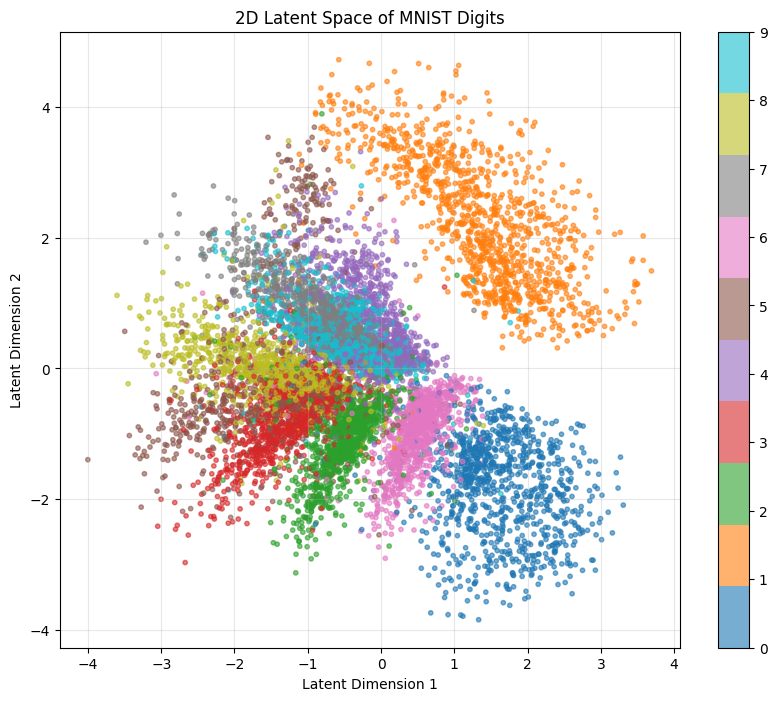

In [ ]:
model.eval()
latent_vectors = []
labels_list = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        latent_vectors.append(mu.cpu().numpy())
        labels_list.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels_list, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D Latent Space of MNIST Digits")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, alpha=0.3)
plt.savefig("latent_space_scatter.png")
plt.show()

Generate the Decoded Image Grid

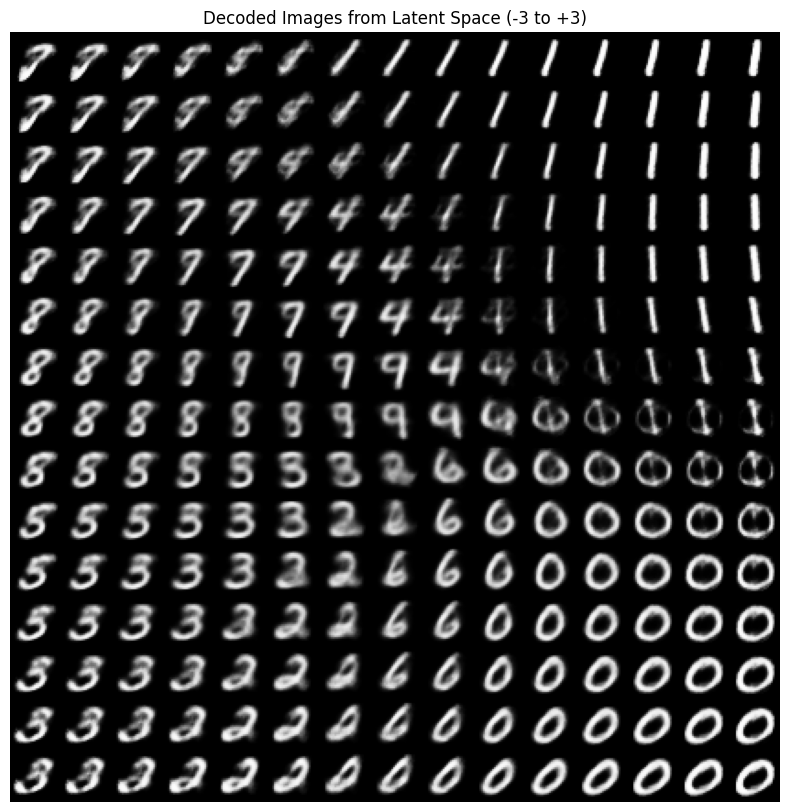

In [ ]:
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(3, -3, n)

model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded.view(digit_size, digit_size).cpu().numpy()

            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.title("Decoded Images from Latent Space (-3 to +3)")
plt.axis('off')
plt.savefig("decoded_image_grid.png")
plt.show()

In this project, I designed and trained a Variational Autoencoder (VAE) using PyTorch to learn a continuous, structured 2-dimensional latent space from the MNIST handwritten digit dataset. The model architecture features an encoder, a reparameterization layer, and a decoder, which were trained over 20 epochs. During training, I separately computed and tracked the reconstruction loss (to ensure accurate digit recreation) and the KL-divergence loss (to enforce a smooth, normal distribution in the latent space). To evaluate the model's performance, I generated a 2D scatter plot of the encoded test images, which successfully demonstrated that similar digits naturally cluster together despite some overlap due to the tight 2D bottleneck. Finally, I sampled evenly spaced points from -3 to +3 across the latent space and passed them through the decoder, producing an image grid that visually proved the VAE's ability to smoothly and continuously morph distinct digit structures into one another without degrading into static noise.